# Linear Regression with Python

Linear Regression in Python - Full Project for Beginners by Alejandro AO  

Project Goal: Predict how much a customer will spend per year.

- Video: https://www.youtube.com/watch?v=O2Cw82YR5Bo  
- Code: https://github.com/alejandro-ao/py-ecommerce-spending-predictions
- Dataset: https://www.kaggle.com/datasets/kolawale/focusing-on-mobile-app-or-website/data

## Import data

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../data/Ecommerce.csv")
df.head()

,Email,Address,Avatar,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
0,mstephenson@fernandez.com,"835 Frank Tunnel\nWrightmouth, MI 82180-9605",Violet,34.497268,12.655651,39.577668,4.082621,587.951054
1,hduke@hotmail.com,"4547 Archer Common\nDiazchester, CA 06566-8576",DarkGreen,31.926272,11.109461,37.268959,2.664034,392.204933
2,pallen@yahoo.com,"24645 Valerie Unions Suite 582\nCobbborough, D...",Bisque,33.000915,11.330278,37.110597,4.104543,487.547505
3,riverarebecca@gmail.com,"1414 David Throughway\nPort Jason, OH 22070-1220",SaddleBrown,34.305557,13.717514,36.721283,3.120179,581.852344
4,mstephens@davidson-herman.com,"14023 Rodriguez Passage\nPort Jacobville, PR 3...",MediumAquaMarine,33.330673,12.795189,37.536653,4.446308,599.406092


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Email                 500 non-null    str    
 1   Address               500 non-null    str    
 2   Avatar                500 non-null    str    
 3   Avg. Session Length   500 non-null    float64
 4   Time on App           500 non-null    float64
 5   Time on Website       500 non-null    float64
 6   Length of Membership  500 non-null    float64
 7   Yearly Amount Spent   500 non-null    float64
dtypes: float64(5), str(3)
memory usage: 31.4 KB


In [4]:
df.describe()

,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
count,500.000000,500.000000,500.000000,500.000000,500.000000
mean,33.053194,12.052488,37.060445,3.533462,499.314038
std,0.992563,0.994216,1.010489,0.999278,79.314782
min,29.532429,8.508152,33.913847,0.269901,256.670582
25%,32.341822,11.388153,36.349257,2.930450,445.038277
50%,33.082008,11.983231,37.069367,3.533975,498.887875
75%,33.711985,12.753850,37.716432,4.126502,549.313828
max,36.139662,15.126994,40.005182,6.922689,765.518462


## Exploratory Data Analysis

Using joint plots to individually see what relationships exists with Yearly Amount Spent, there does not seem to be a correlation with Time on Website; however, there is a faint positive correlation with Time on App.

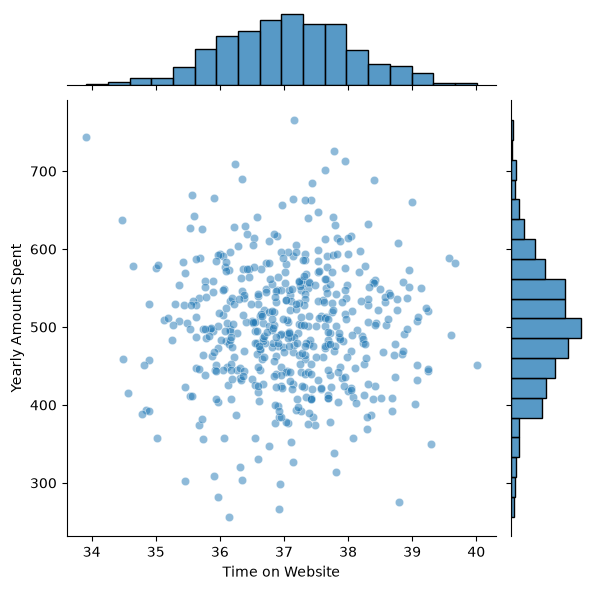

In [5]:
sns.jointplot(x="Time on Website", 
              y="Yearly Amount Spent", 
              data=df, alpha=0.5)

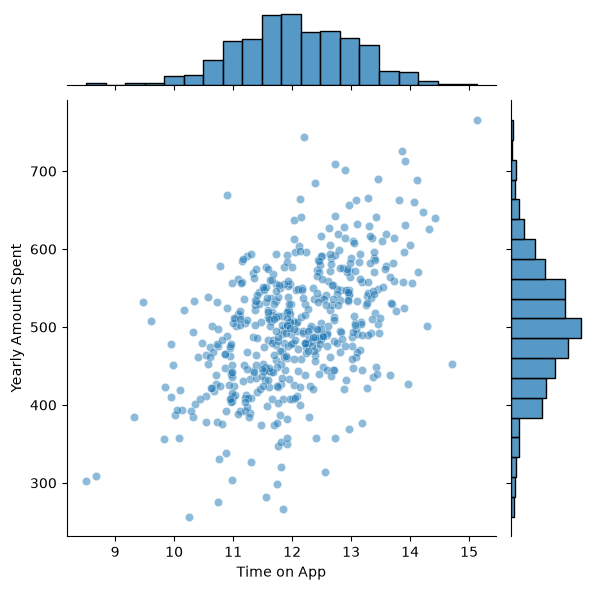

In [6]:
sns.jointplot(x="Time on App", 
              y="Yearly Amount Spent", 
              data=df, alpha=0.5)

Alternatively, we can use pair plots to view the relationships across all the data. Looking only at Yearly Amount Spent, there is a strong positive relationship with Length of Membership.

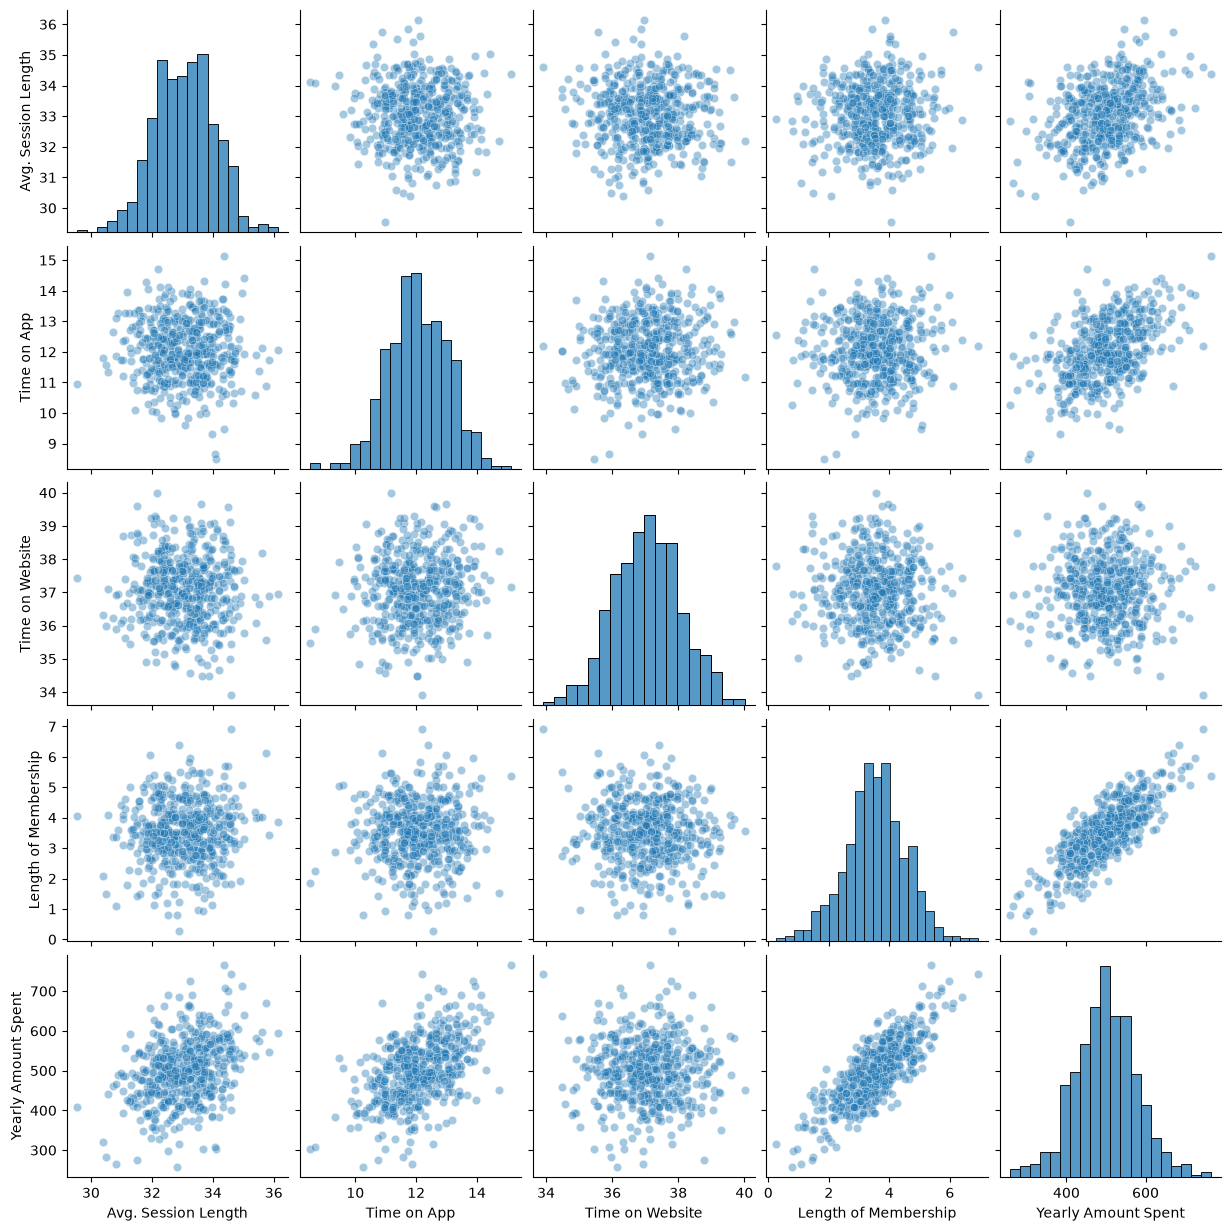

In [7]:
sns.pairplot(df, kind='scatter', plot_kws={'alpha': 0.4})

## Linear regression model with Ordinary Least Squares (OLS)

As described in lecture, the model function for linear regression (which is a function that maps from `x` to `y`) is represented as 

$$ f_{w,b}(x^{(i)}) = wx^{(i)} + b \tag{1}$$

In linear regression, you utilize input training data to fit the parameters $w$,$b$ by minimizing a measure of the error between our predictions $f_{w,b}(x^{(i)})$ and the actual data $y^{(i)}$. The measure is called the $cost$.

### Plotting the model
Let's first plot our linear model of Length of Membership vs. Yearly Amount Spent. 

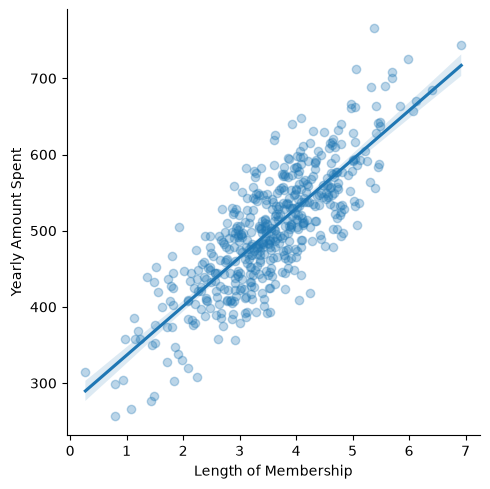

In [8]:
sns.lmplot(x="Length of Membership", 
           y="Yearly Amount Spent", 
           data=df, 
           scatter_kws={'alpha': 0.3})

### Splitting the data
To make a prediction of amount spent per year based on a given membership length (and any other variables), we need to train a model. We will need to split our data into a training set (70%) and testing set (30%) to validate our model's predictions.

In [9]:
from sklearn.model_selection import train_test_split

x = df[['Avg. Session Length', 'Time on App', 'Time on Website', 'Length of Membership']]
y = df['Yearly Amount Spent']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42)

# check output
x_train

ModuleNotFoundError: No module named 'sklearn'

### Training the multivariate regression model

In [ ]:
from sklearn.linear_model import LinearRegression

lm = LinearRegression()
lm.fit(x_train, y_train)

The model will return one coefficient per variable to represent the variable's weight $w$ for the model. This linear model looks like 
$$ \hat{y} = \hat{\beta_0} + \hat{\beta_1}x_1 + \hat{\beta_2}x_2 + \hat{\beta_3}x_3 + \hat{\beta_4}x_4$$

In [ ]:
lm.coef_

In [ ]:
cdf = pd.DataFrame(lm.coef_, x.columns, columns=['Coef'])
print(cdf)

### Analytical Evaluation of Model
Next we will check the model by having it make predictions using the testing set. If a plot of prediction vs. actual yields a straight line, the model fits the test data well.

In [ ]:
pred = lm.predict(x_test)
pred

In [ ]:
# Plot predicted y against actual y
sns.scatterplot(x=pred, y=y_test)
plt.xlabel("Predictions")
plt.title("Linear Regression Model Evaluation")

To quantitatively evaluate our model, we can look at some values related to the model errors. The unit of these values matches the unit of your target variable `y`, in this case `$`.

- Mean Absolute Error (MSA): measures the average of absolute differences between predictions and actual values
- Mean Squared Error (MSE): squares the absolute differences before averaging them, penalizing larger errors more heavily
- Root Mean Squared Error (RMSE): acts as a compromise. Like MSE, it severely penalizes larger errors because the squaring happens first. However, by taking the square root at the end, it returns the error metric to the original units of the target variable, making it more interpretable.

In [ ]:
# Evaluation of model errors
from sklearn.metrics import mean_squared_error, mean_absolute_error
import math

print("Mean Absolute Error: ", mean_absolute_error(y_test, pred))
print("Mean Squared Error: ", mean_squared_error(y_test, pred))
print("Root Mean Squared Error: ", math.sqrt(mean_squared_error(y_test, pred)))

  Using cached scikit_learn-1.9.0-cp314-cp314-macosx_12_0_arm64.whl.metadata (11 kB)
  Using cached scipy-1.17.1-cp314-cp314-macosx_14_0_arm64.whl.metadata (62 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.2/8.2 MB 58.4 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.3/20.3 MB 37.3 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 31.6 MB/s  0:00:00eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [statsmodels] [statsmodels]]
Note: you may need to restart the kernel to use updated packages.


NameError: name 'y_test' is not defined

Linear models assume that the residuals of the predictions are normally distributed. If they are not normally distributed, the model may be biased.

In [ ]:
# Residual analysis
# Method 1: Histogram - check for normal distribution
resid = y_test - pred
sns.displot(resid, bins=20, kde=True)

In [ ]:
# Method 2: QQ Plot - check for straight line
import pylab
import scipy.stats as stats

stats.probplot(resid, dist="norm", plot=pylab)
pylab.show()

## Alternative OLS training method
This provides additional information, such as statistical inference and regression diagnostics.

In [ ]:
import statsmodels.api as sm

x = sm.add_constant(x_train)
model = sm.OLS(y_train, x)
model_fit = model.fit()
print(model_fit.summary())

## Conclusion
According to the model, the most significant factor of amount spent per year for clients is length of membership.